# CAPM de Bitcoin: NCI vs S&P 500, con y sin HAC

**Periodo:** 2021-08-25 a 2026-08-24

Este cuaderno:
1. Descarga desde FRED la serie diaria **DTB3** (T-Bill de 3 meses, discount basis).
2. Convierte la tasa de porcentaje a decimal y a una tasa diaria.
3. Limpia y alinea `df_btc` con los días en que existe T-Bill y con cada benchmark.
4. Estima cuatro CAPM:
   - BTC vs NCI, OLS convencional
   - BTC vs S&P 500, OLS convencional
   - BTC vs NCI, OLS con errores estándar HAC
   - BTC vs S&P 500, OLS con errores estándar HAC
5. Presenta una tabla final con **alfa, beta y R²**.

> **Nota metodológica:** HAC (Newey-West) corrige la matriz de varianzas/covarianzas de los coeficientes frente a heterocedasticidad y autocorrelación; no cambia los coeficientes OLS ni el R². Por eso las cuatro estimaciones tendrán los mismos alfa, beta y R² para cada benchmark, aunque cambien los errores estándar, t-stat y p-values.

## 1. Librerías y configuración

In [ ]:
!pip -q install statsmodels pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from google.colab import files
from IPython.display import display

START_DATE = "2021-08-25"
END_DATE   = "2026-08-24"

# Número de rezagos para Newey-West/HAC.
# 5 equivale a una ventana de aproximadamente una semana de días hábiles.
HAC_LAGS = 5

pd.set_option("display.float_format", lambda x: f"{x:,.8f}")

## 2. Cargar los datasets

Si `df_btc`, `df_nci` y `df_gspc` ya existen en el entorno, esta celda los conserva. Si no existen, permite subir los tres CSV.

Los archivos proporcionados utilizan `;` como separador.

In [ ]:
# Si las variables ya existen, no se vuelven a cargar.
try:
    df_btc
    df_nci
    df_gspc
    print("Los DataFrames ya estaban cargados.")
except NameError:
    print("Sube los tres archivos CSV: df_btc.csv, df_nci.csv y df_gspc.csv")
    uploaded = files.upload()

    def read_uploaded_csv(name):
        if name not in uploaded:
            raise FileNotFoundError(f"No se encontró {name}.")
        return pd.read_csv(name, sep=";")

    df_btc = read_uploaded_csv("df_btc.csv")
    df_nci = read_uploaded_csv("df_nci.csv")
    df_gspc = read_uploaded_csv("df_gspc.csv")

print("BTC:", df_btc.shape)
print("NCI:", df_nci.shape)
print("S&P 500:", df_gspc.shape)

Sube los tres archivos CSV: df_btc.csv, df_nci.csv y df_gspc.csv


Saving df_gspc.csv to df_gspc.csv
Saving df_nci.csv to df_nci.csv
Saving df_btc.csv to df_btc.csv
BTC: (1825, 10)
NCI: (1254, 6)
S&P 500: (1253, 8)


## 3. Estandarizar fechas y retornos

Los archivos tienen formatos de fecha diferentes:
- BTC y S&P 500: `dd/mm/yyyy`
- NCI: `mm/dd/yyyy`

Se utilizan los `Log_Returns` ya presentes en los datasets. Si alguno no estuviera disponible, se puede calcular a partir del precio de cierre.

In [ ]:
def prepare_returns(df, name, date_format):
    out = df.copy()

    # Fecha
    out["Date"] = pd.to_datetime(out["Date"], format=date_format, errors="coerce")
    out = out.dropna(subset=["Date"]).copy()

    # Retorno logarítmico
    if "Log_Returns" not in out.columns:
        out["Log_Returns"] = np.nan

    out["Log_Returns"] = pd.to_numeric(out["Log_Returns"], errors="coerce")

    # Si hay retornos faltantes y existe Close, intentamos calcularlos.
    if "Close" in out.columns:
        close = pd.to_numeric(
            out["Close"].astype(str).str.replace(".", "", regex=False),
            errors="coerce"
        )
        calculated = np.log(close / close.shift(1))
        out["Log_Returns"] = out["Log_Returns"].fillna(calculated)

    out = out[["Date", "Log_Returns"]].copy()
    out = out.rename(columns={"Log_Returns": f"r_{name}"})
    out = out.drop_duplicates("Date").sort_values("Date")

    return out

btc_r = prepare_returns(df_btc, "BTC", "%d/%m/%Y")
nci_r = prepare_returns(df_nci, "NCI", "%m/%d/%Y")
sp_r  = prepare_returns(df_gspc, "SP500", "%d/%m/%Y")

for x, name in [(btc_r, "BTC"), (nci_r, "NCI"), (sp_r, "S&P500")]:
    print(f"{name}: {x['Date'].min().date()} → {x['Date'].max().date()} | n={len(x):,}")

BTC: 2021-08-25 → 2026-08-23 | n=1,825
NCI: 2021-08-25 → 2026-08-24 | n=1,254
S&P500: 2021-08-25 → 2026-08-21 | n=1,253


## 4. Extraer el T-Bill de 3 meses desde FRED

La serie utilizada es **DTB3**, "3-Month Treasury Bill Secondary Market Rate, Discount Basis", frecuencia diaria y expresada en porcentaje. La fuente es la Board of Governors of the Federal Reserve System a través de FRED.

Se limita al periodo solicitado. Los valores `.` de FRED representan observaciones faltantes y se eliminan antes de hacer el cruce de fechas.

### Conversión a tasa diaria

Primero:

\[
r_{f,annual} = \frac{DTB3}{100}
\]

Luego se utiliza una conversión efectiva sobre 252 días hábiles:

\[
r_{f,daily}=(1+r_{f,annual})^{1/252}-1
\]

Esto es preferible a simplemente dividir entre 252 cuando se quiere expresar una tasa efectiva diaria. **DTB3 está cotizada sobre base de descuento**, por lo que esta transformación debe entenderse como una aproximación operativa para el CAPM. Si tu profesor exige una convención específica (por ejemplo, tasa nominal/252), se puede cambiar fácilmente en la celda.

In [ ]:
FRED_URL = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv"
    "?id=DTB3&cosd=2021-08-25&coed=2026-08-24"
)

rf = pd.read_csv(FRED_URL)

rf["observation_date"] = pd.to_datetime(rf["observation_date"], errors="coerce")
rf["DTB3"] = pd.to_numeric(rf["DTB3"], errors="coerce")

rf = rf.rename(columns={"observation_date": "Date", "DTB3": "rf_percent"})
rf = rf.dropna(subset=["Date", "rf_percent"]).copy()

# 1) Porcentaje -> decimal
rf["rf_annual"] = rf["rf_percent"] / 100

# 2) Decimal anual -> decimal diario efectivo
rf["rf_daily"] = (1 + rf["rf_annual"]) ** (1/252) - 1

rf = rf[
    (rf["Date"] >= START_DATE) &
    (rf["Date"] <= END_DATE)
].copy()

rf = rf[["Date", "rf_percent", "rf_annual", "rf_daily"]].sort_values("Date")

print(f"Observaciones T-Bill: {len(rf):,}")
print(f"Periodo FRED disponible: {rf['Date'].min().date()} → {rf['Date'].max().date()}")
display(rf.head())
display(rf.tail())

Observaciones T-Bill: 1,248
Periodo FRED disponible: 2021-08-25 → 2026-08-24


,Date,rf_percent,rf_annual,rf_daily
0,2021-08-25,0.06000000,0.00060000,0.00000238
1,2021-08-26,0.05000000,0.00050000,0.00000198
2,2021-08-27,0.05000000,0.00050000,0.00000198
3,2021-08-30,0.05000000,0.00050000,0.00000198
4,2021-08-31,0.04000000,0.00040000,0.00000159


,Date,rf_percent,rf_annual,rf_daily
1299,2026-08-18,3.71000000,0.03710000,0.00014457
1300,2026-08-19,3.71000000,0.03710000,0.00014457
1301,2026-08-20,3.71000000,0.03710000,0.00014457
1302,2026-08-21,3.72000000,0.03720000,0.00014495
1303,2026-08-24,3.72000000,0.03720000,0.00014495


## 5. Construir la base común de fechas

BTC cotiza 24/7, mientras que el T-Bill y los índices bursátiles no. Para cada modelo usamos únicamente las fechas donde existen:
- retorno de BTC,
- tasa libre de riesgo,
- retorno del benchmark.

Esto evita imputar retornos de mercado o de T-Bill en días donde no hubo observación.

In [ ]:
def build_capm_dataset(market_df, market_name):
    data = (
        btc_r
        .merge(rf, on="Date", how="inner")
        .merge(market_df, on="Date", how="inner")
        .sort_values("Date")
        .dropna(subset=["r_BTC", "rf_daily", f"r_{market_name}"])
        .copy()
    )

    # Retornos en exceso
    data["excess_BTC"] = data["r_BTC"] - data["rf_daily"]
    data["excess_market"] = data[f"r_{market_name}"] - data["rf_daily"]

    return data

capm_nci = build_capm_dataset(nci_r, "NCI")
capm_sp   = build_capm_dataset(sp_r, "SP500")

print("BTC vs NCI")
print(capm_nci[["Date", "r_BTC", "rf_daily", "r_NCI"]].head())
print("n =", len(capm_nci))

print("\nBTC vs S&P 500")
print(capm_sp[["Date", "r_BTC", "rf_daily", "r_SP500"]].head())
print("n =", len(capm_sp))

BTC vs NCI
        Date       r_BTC   rf_daily       r_NCI
1 2021-08-26 -0.04210230 0.00000198 -0.05064543
2 2021-08-27  0.04409943 0.00000198  0.03591516
3 2021-08-30 -0.03702464 0.00000198 -0.02752052
4 2021-08-31  0.00237107 0.00000159 -0.05929782
5 2021-09-01  0.03500565 0.00000198 -0.00582623
n = 1243

BTC vs S&P 500
        Date       r_BTC   rf_daily     r_SP500
1 2021-08-26 -0.04210230 0.00000198 -0.00584195
2 2021-08-27  0.04409943 0.00000198  0.00876907
3 2021-08-30 -0.03702464 0.00000198  0.00429732
4 2021-08-31  0.00237107 0.00000159 -0.00135003
5 2021-09-01  0.03500565 0.00000198  0.00031164
n = 1243


## 6. Especificación del CAPM

Para cada benchmark estimamos:

\[
R_{BTC,t}-R_{f,t}
=
\alpha
+
\beta(R_{M,t}-R_{f,t})
+
\epsilon_t
\]

donde:
- **α (alfa):** rendimiento anormal/intercepto.
- **β (beta):** sensibilidad de BTC frente al mercado.
- **R²:** proporción de la variación del exceso de retorno de BTC explicada por el exceso de retorno del mercado.

Se estiman dos versiones:
1. OLS convencional.
2. OLS con matriz de varianzas/covarianzas **HAC (Newey-West)**.

Con HAC, los coeficientes estimados por OLS permanecen iguales; lo que cambia es su inferencia estadística.

In [ ]:
def estimate_capm(data, market_name, hac=False, maxlags=5):
    y = data["excess_BTC"]
    X = sm.add_constant(data["excess_market"])

    if hac:
        model = sm.OLS(y, X).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": maxlags}
        )
    else:
        model = sm.OLS(y, X).fit()

    return model

models = {
    "BTC vs NCI — OLS": estimate_capm(capm_nci, "NCI", hac=False),
    "BTC vs S&P 500 — OLS": estimate_capm(capm_sp, "SP500", hac=False),
    "BTC vs NCI — HAC": estimate_capm(capm_nci, "NCI", hac=True, maxlags=HAC_LAGS),
    "BTC vs S&P 500 — HAC": estimate_capm(capm_sp, "SP500", hac=True, maxlags=HAC_LAGS),
}

for name, model in models.items():
    print("\n" + "="*80)
    print(name)
    print(model.summary())


BTC vs NCI — OLS
                            OLS Regression Results                            
Dep. Variable:             excess_BTC   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.02590
Date:                Mon, 07 Sep 2026   Prob (F-statistic):              0.872
Time:                        18:35:32   Log-Likelihood:                 319.83
No. Observations:                1243   AIC:                            -635.7
Df Residuals:                    1241   BIC:                            -625.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.0077    

## 7. Tabla final: alfa, beta y R² de los cuatro modelos

In [ ]:
results = []

for name, model in models.items():
    results.append({
        "Modelo": name,
        "Alfa": model.params["const"],
        "Beta": model.params["excess_market"],
        "R²": model.rsquared,
        "Error estándar alfa": model.bse["const"],
        "Error estándar beta": model.bse["excess_market"],
        "p-value alfa": model.pvalues["const"],
        "p-value beta": model.pvalues["excess_market"],
        "N": int(model.nobs)
    })

results_df = pd.DataFrame(results)

# Tabla solicitada
tabla_final = results_df[["Modelo", "Alfa", "Beta", "R²"]].copy()

display(
    tabla_final.style.format({
        "Alfa": "{:.8f}",
        "Beta": "{:.8f}",
        "R²": "{:.6f}"
    })
)

,Modelo,Alfa,Beta,R²
0,BTC vs NCI — OLS,-0.00767878,-0.01153932,0.000021
1,BTC vs S&P 500 — OLS,-0.00769503,0.00046677,0.000002
2,BTC vs NCI — HAC,-0.00767878,-0.01153932,0.000021
3,BTC vs S&P 500 — HAC,-0.00769503,0.00046677,0.000002


## 8. Comparación de la inferencia con y sin HAC

Esta tabla permite comprobar algo importante: **HAC no cambia alfa, beta ni R²**. Cambia los errores estándar y, por tanto, los estadísticos t y p-values.

Esto es precisamente lo que debe observarse si HAC se utiliza correctamente como corrección de inferencia sobre la misma regresión OLS.

In [ ]:
inference_df = results_df[
    ["Modelo", "Alfa", "Beta",
     "Error estándar alfa", "Error estándar beta",
     "p-value alfa", "p-value beta"]
].copy()

display(
    inference_df.style.format({
        "Alfa": "{:.8f}",
        "Beta": "{:.8f}",
        "Error estándar alfa": "{:.8f}",
        "Error estándar beta": "{:.8f}",
        "p-value alfa": "{:.6f}",
        "p-value beta": "{:.6f}"
    })
)

,Modelo,Alfa,Beta,Error estándar alfa,Error estándar beta,p-value alfa,p-value beta
0,BTC vs NCI — OLS,-0.00767878,-0.01153932,0.00531138,0.07169976,0.148508,0.872167
1,BTC vs S&P 500 — OLS,-0.00769503,0.00046677,0.00531049,0.00866656,0.147583,0.957056
2,BTC vs NCI — HAC,-0.00767878,-0.01153932,0.00524761,0.02069089,0.143388,0.577049
3,BTC vs S&P 500 — HAC,-0.00769503,0.00046677,0.00526142,0.00081194,0.143594,0.565370


## 9. Diagnóstico visual de los residuos

Los gráficos no son necesarios para obtener la tabla final, pero ayudan a justificar por qué tiene sentido comparar OLS convencional con HAC. En particular, HAC es útil cuando los residuos presentan heterocedasticidad y/o autocorrelación.

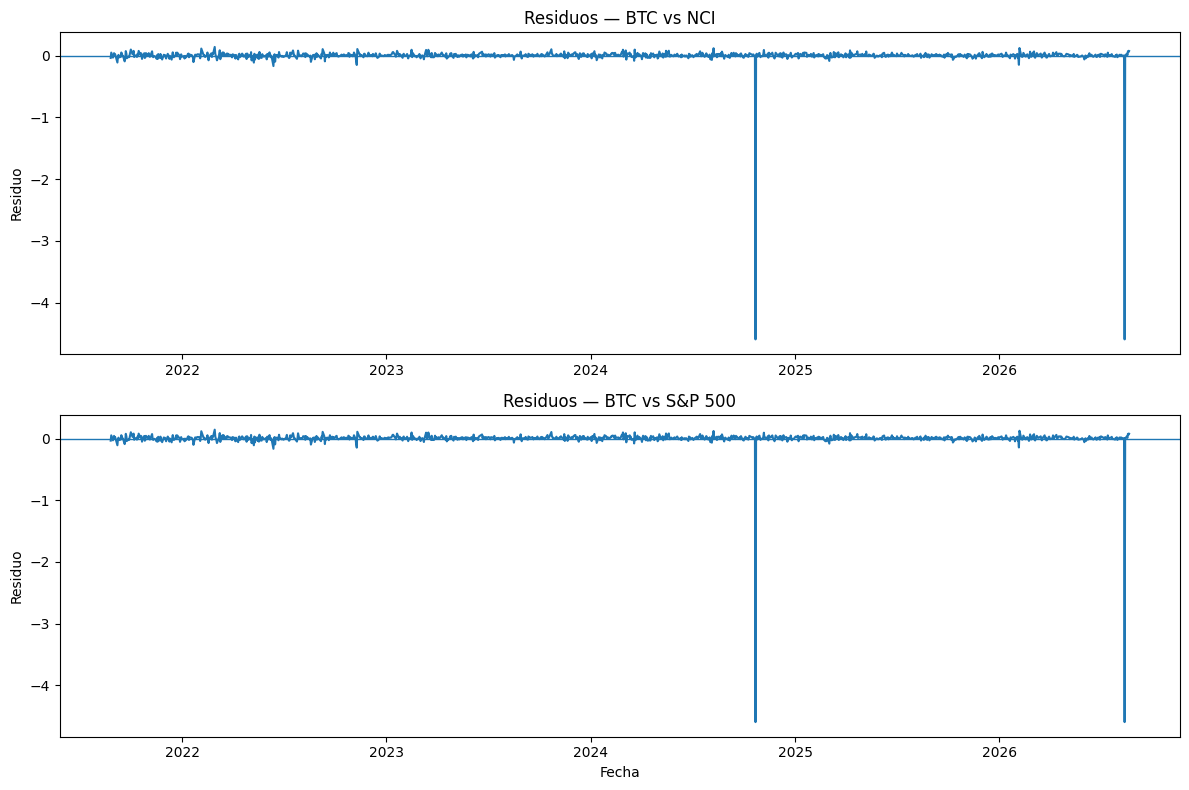

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(capm_nci["Date"], models["BTC vs NCI — OLS"].resid)
axes[0].axhline(0, linewidth=1)
axes[0].set_title("Residuos — BTC vs NCI")
axes[0].set_ylabel("Residuo")

axes[1].plot(capm_sp["Date"], models["BTC vs S&P 500 — OLS"].resid)
axes[1].axhline(0, linewidth=1)
axes[1].set_title("Residuos — BTC vs S&P 500")
axes[1].set_ylabel("Residuo")
axes[1].set_xlabel("Fecha")

plt.tight_layout()
plt.show()

## 10. Exportar resultados

Se guardan:
- la tabla final de alfa, beta y R²;
- la tabla completa de inferencia;
- las bases alineadas de BTC-NCI y BTC-S&P 500.

In [ ]:
tabla_final.to_csv("CAPM_BTC_resultados.csv", index=False)
inference_df.to_csv("CAPM_BTC_inferencia.csv", index=False)
capm_nci.to_csv("CAPM_BTC_NCI_base_alineada.csv", index=False)
capm_sp.to_csv("CAPM_BTC_SP500_base_alineada.csv", index=False)

print("Archivos generados:")
print("- CAPM_BTC_resultados.csv")
print("- CAPM_BTC_inferencia.csv")
print("- CAPM_BTC_NCI_base_alineada.csv")
print("- CAPM_BTC_SP500_base_alineada.csv")

Archivos generados:
- CAPM_BTC_resultados.csv
- CAPM_BTC_inferencia.csv
- CAPM_BTC_NCI_base_alineada.csv
- CAPM_BTC_SP500_base_alineada.csv


# Interpretación final

Para interpretar los resultados:

- **Alfa > 0:** BTC presenta, en promedio, un exceso de rendimiento positivo no explicado por el benchmark.
- **Alfa < 0:** exceso de rendimiento negativo.
- **Beta > 1:** BTC es más sensible que el mercado elegido.
- **Beta < 1:** BTC es menos sensible que el mercado elegido.
- **Beta negativa:** BTC tiende a moverse en sentido contrario al benchmark.
- **R² alto:** el benchmark explica una mayor proporción de la variabilidad del exceso de retorno de BTC.
- **R² bajo:** gran parte de la variabilidad de BTC queda sin explicar por ese benchmark.

### Punto metodológico clave

No debe interpretarse que el modelo HAC tiene un beta distinto al modelo OLS. En este caso, HAC mantiene la misma estimación puntual de alfa y beta y modifica principalmente los **errores estándar, t-statistics y p-values**. Por ello, la comparación OLS vs HAC debe centrarse especialmente en la significancia estadística y no en cambios de los coeficientes.

### Fuente del T-Bill

FRED: serie **DTB3**, 3-Month Treasury Bill Secondary Market Rate, Discount Basis, frecuencia diaria, fuente Board of Governors of the Federal Reserve System.

## Métricas adicionales y Beta bajista

Se añaden Sharpe, Sortino, máximo drawdown, VaR histórico 95%, CVaR 95% y beta bajista. HAC no cambia los coeficientes alfa/beta/R²; sí cambia sus errores estándar y p-values.

In [ ]:
# MÉTRICAS DE DESEMPEÑO Y RIESGO + BETA BAJISTA
import numpy as np
import pandas as pd
import statsmodels.api as sm
TRADING_DAYS=252

def calcular_metricas(df, return_col='Log_Returns', rf_col='rf_daily'):
    d=df.copy(); d[return_col]=pd.to_numeric(d[return_col],errors='coerce'); d=d.dropna(subset=[return_col]); r=d[return_col].astype(float)
    rf=pd.to_numeric(d[rf_col],errors='coerce').fillna(0) if rf_col in d.columns else 0
    ex=r-rf
    sharpe=ex.mean()/ex.std(ddof=1)*np.sqrt(TRADING_DAYS)
    dd=np.minimum(ex,0); down=np.sqrt(np.mean(dd**2)); sortino=ex.mean()/down*np.sqrt(TRADING_DAYS) if down>0 else np.nan
    wealth=(1+r).cumprod(); drawdown=wealth/wealth.cummax()-1; max_dd=drawdown.min()
    q=r.quantile(.05); var=-q; cvar=-r[r<=q].mean()
    return {'Sharpe':sharpe,'Sortino':sortino,'Max Drawdown':max_dd,'VaR 95%':var,'CVaR 95%':cvar}

def beta_normal_y_bajista(df, asset_excess_col, market_excess_col):
    d=df[[asset_excess_col,market_excess_col]].dropna(); X=sm.add_constant(d[market_excess_col]); y=d[asset_excess_col]
    beta=sm.OLS(y,X).fit().params[market_excess_col]
    down=d[d[market_excess_col]<0]
    beta_down=down[asset_excess_col].cov(down[market_excess_col])/down[market_excess_col].var(ddof=1) if len(down)>1 and down[market_excess_col].var(ddof=1)>0 else np.nan
    return beta,beta_down

# Tabla de métricas del activo (el dataset debe contener Log_Returns y, si se desea, rf_daily)
activo_df = df_btc if 'df_btc' in globals() else df_goss
nombre = 'Bitcoin' if 'df_btc' in globals() else 'GOSS'
tabla_metricas = pd.DataFrame([calcular_metricas(activo_df)]); tabla_metricas.insert(0,'Activo',nombre)
display(tabla_metricas.style.format({'Sharpe':'{:.4f}','Sortino':'{:.4f}','Max Drawdown':'{:.2%}','VaR 95%':'{:.2%}','CVaR 95%':'{:.2%}'}))


,Activo,Sharpe,Sortino,Max Drawdown,VaR 95%,CVaR 95%
0,Bitcoin,0.1478,0.2083,-81.53%,4.19%,6.54%


## Tabla de beta normal y beta bajista

Usa las bases alineadas creadas en las celdas de los modelos. Ejemplo para Bitcoin: `{'NCI': df_btc_nci, 'S&P 500': df_btc_sp500}`. Para GOSS: `{'NBI': df_goss_nbi, 'XBI': df_goss_xbi, 'S&P 500': df_goss_sp500}`. Ajusta los nombres si tus celdas usan nombres diferentes.

In [ ]:
# EJEMPLO DE CÁLCULO POR MERCADO
# Descomenta y adapta los nombres de columnas/dataframes si es necesario.
# bases_alineadas = {'NCI': df_btc_nci, 'S&P 500': df_btc_sp500}
# bases_alineadas = {'NBI': df_goss_nbi, 'XBI': df_goss_xbi, 'S&P 500': df_goss_sp500}
# filas=[]
# for mercado, d in bases_alineadas.items():
#     beta,beta_down=beta_normal_y_bajista(d,'excess_asset','excess_market')
#     filas.append({'Mercado':mercado,'Beta':beta,'Beta bajista':beta_down})
# tabla_betas=pd.DataFrame(filas)
# display(tabla_betas.style.format({'Beta':'{:.4f}','Beta bajista':'{:.4f}'}))


## Tabla final: CAPM + métricas de riesgo

Esta tabla integra los resultados econométricos y las métricas de desempeño y riesgo para cada mercado, tanto sin HAC como con HAC.

## Tabla final integral: CAPM, riesgo y beta bajista

Esta sección usa directamente las bases CAPM ya alineadas (`capm_*`) creadas anteriormente en el notebook. Así se evita depender de nombres automáticos de columnas y se garantiza que todos los modelos utilizan exactamente las mismas observaciones que las regresiones CAPM.

In [ ]:

# ============================================================
# TABLA FINAL INTEGRAL
# ============================================================

TRADING_DAYS = 252
CONFIDENCE = 0.95

def metricas_riesgo_alineadas(data, return_col, rf_col="rf_daily"):
    d = data.copy()
    r = pd.to_numeric(d[return_col], errors="coerce")
    rf = pd.to_numeric(d[rf_col], errors="coerce")
    valid = pd.concat([r, rf], axis=1).dropna()
    r = valid[return_col]
    rf = valid[rf_col]
    excess = r - rf

    sharpe = excess.mean() / excess.std(ddof=1) * np.sqrt(TRADING_DAYS)

    downside = np.minimum(excess, 0)
    downside_dev = np.sqrt(np.mean(downside**2))
    sortino = (
        excess.mean() / downside_dev * np.sqrt(TRADING_DAYS)
        if downside_dev > 0 else np.nan
    )

    wealth = (1 + r).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    max_dd = drawdown.min()

    q05 = r.quantile(0.05)
    var95 = -q05
    cvar95 = -r[r <= q05].mean()

    return sharpe, sortino, max_dd, var95, cvar95


def beta_bajista(data, asset_excess_col="excess_BTC",
                 market_excess_col="excess_market"):
    d = data[[asset_excess_col, market_excess_col]].dropna().copy()
    down = d[d[market_excess_col] < 0]

    if len(down) < 2 or down[market_excess_col].var(ddof=1) == 0:
        return np.nan

    return (
        down[asset_excess_col].cov(down[market_excess_col])
        / down[market_excess_col].var(ddof=1)
    )


# Bases ya construidas en el notebook
bases = {
    "NCI": capm_nci,
    "S&P 500": capm_sp
}

filas = []

for mercado, data in bases.items():

    # Métricas de riesgo sobre la misma muestra alineada del modelo
    sharpe, sortino, max_dd, var95, cvar95 = metricas_riesgo_alineadas(
        data, "r_BTC"
    )

    # Beta bajista
    beta_down = beta_bajista(data)

    # OLS y HAC
    for especificacion, hac in [("Sin HAC", False), ("HAC", True)]:

        modelo = estimate_capm(
            data,
            mercado,
            hac=hac,
            maxlags=HAC_LAGS
        )

        filas.append({
            "Activo": "Bitcoin",
            "Mercado": mercado,
            "Modelo": especificacion,
            "Alfa": modelo.params["const"],
            "Beta": modelo.params["excess_market"],
            "Beta bajista": beta_down,
            "R²": modelo.rsquared,
            "Sharpe": sharpe,
            "Sortino": sortino,
            "Máximo Drawdown": max_dd,
            "VaR 95%": var95,
            "CVaR 95%": cvar95,
            "p-value Alfa": modelo.pvalues["const"],
            "p-value Beta": modelo.pvalues["excess_market"],
            "N": int(modelo.nobs)
        })

tabla_final = pd.DataFrame(filas)

display(
    tabla_final.style.format({
        "Alfa": "{:.8f}",
        "Beta": "{:.4f}",
        "Beta bajista": "{:.4f}",
        "R²": "{:.4f}",
        "Sharpe": "{:.4f}",
        "Sortino": "{:.4f}",
        "Máximo Drawdown": "{:.2%}",
        "VaR 95%": "{:.2%}",
        "CVaR 95%": "{:.2%}",
        "p-value Alfa": "{:.4f}",
        "p-value Beta": "{:.4f}",
        "N": "{:.0f}"
    })
)

tabla_final.to_csv("CAPM_BTC_tabla_final_integral.csv", index=False)
print("Tabla guardada como CAPM_BTC_tabla_final_integral.csv")


,Activo,Mercado,Modelo,Alfa,Beta,Beta bajista,R²,Sharpe,Sortino,Máximo Drawdown,VaR 95%,CVaR 95%,p-value Alfa,p-value Beta,N
0,Bitcoin,NCI,Sin HAC,-0.00767878,-0.0115,0.0656,0.0000,-0.6527,-0.6566,-375.06%,4.99%,21.63%,0.1485,0.8722,1243
1,Bitcoin,NCI,HAC,-0.00767878,-0.0115,0.0656,0.0000,-0.6527,-0.6566,-375.06%,4.99%,21.63%,0.1434,0.5770,1243
2,Bitcoin,S&P 500,Sin HAC,-0.00769503,0.0005,-0.0029,0.0000,-0.6527,-0.6566,-375.06%,4.99%,21.63%,0.1476,0.9571,1243
3,Bitcoin,S&P 500,HAC,-0.00769503,0.0005,-0.0029,0.0000,-0.6527,-0.6566,-375.06%,4.99%,21.63%,0.1436,0.5654,1243


Tabla guardada como CAPM_BTC_tabla_final_integral.csv


## Gráficos para analizar y sustentar los resultados

Los gráficos se generan con las bases y resultados reales del modelo. Sirven para sustentar visualmente riesgo, ajuste, sensibilidad y comportamiento bajista.

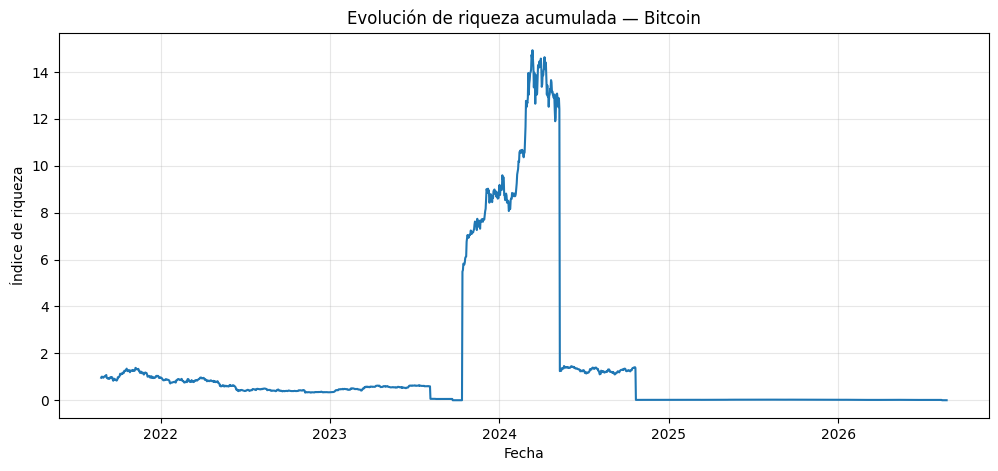

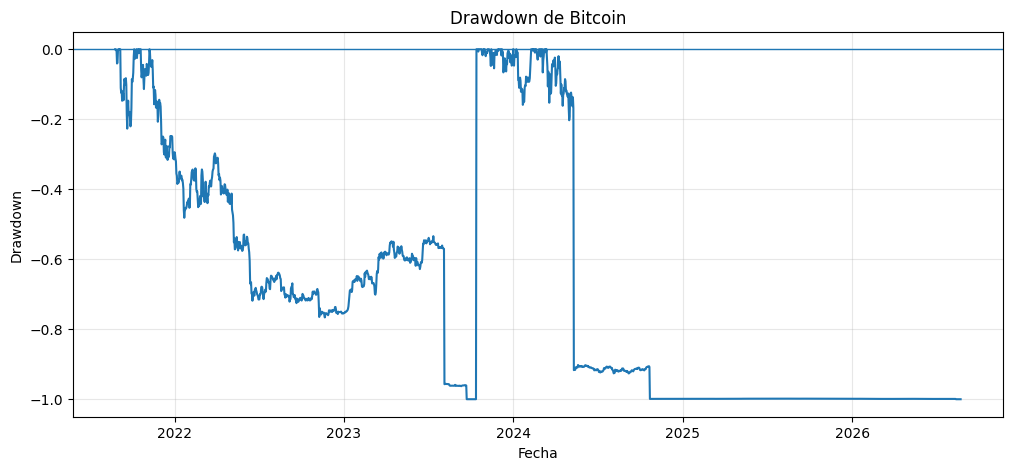

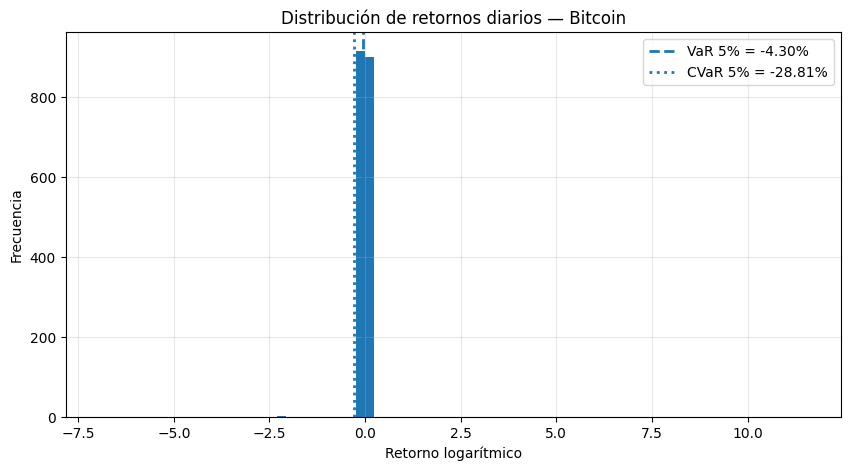

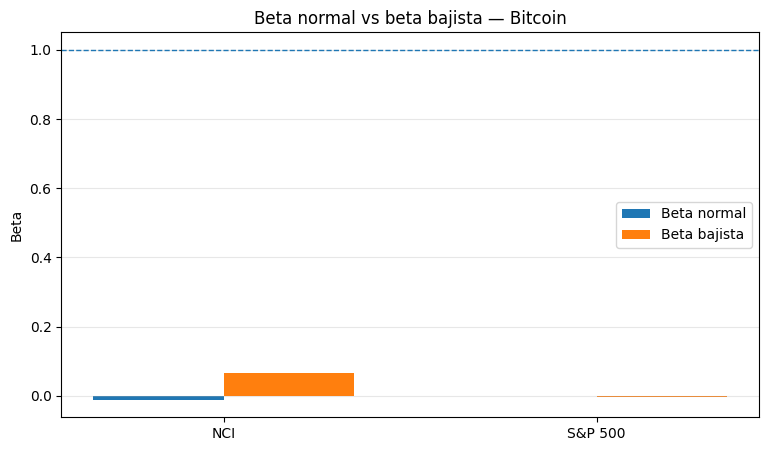

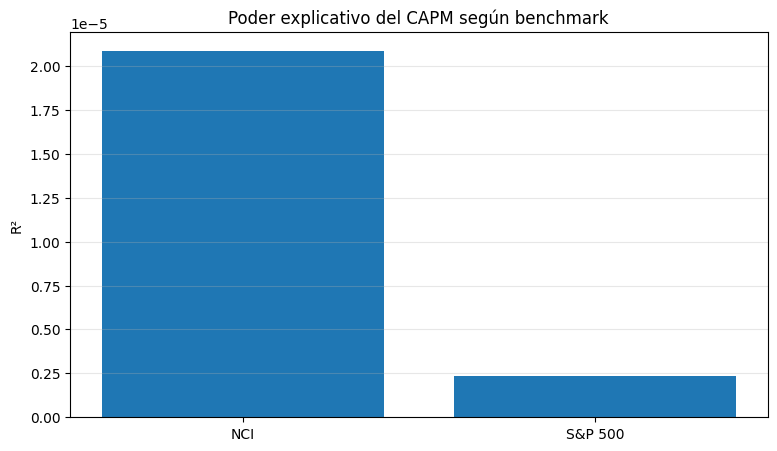

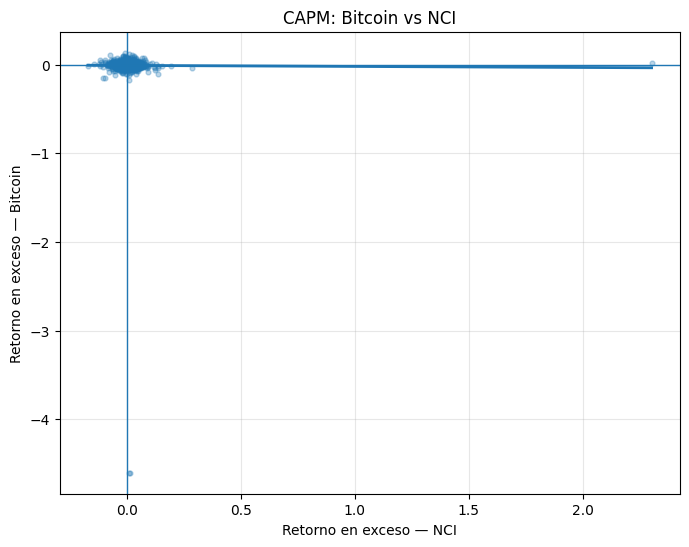

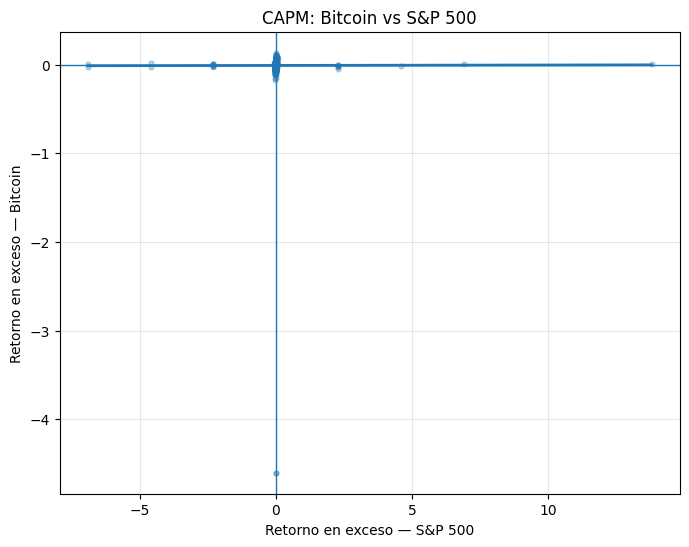

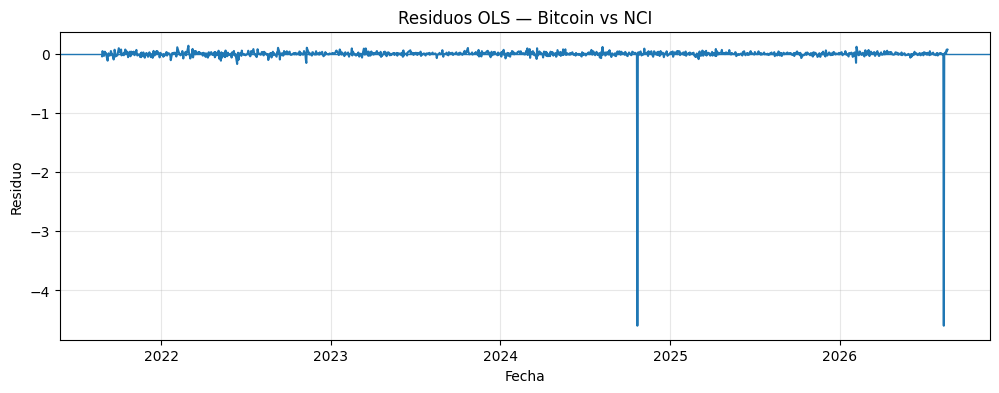

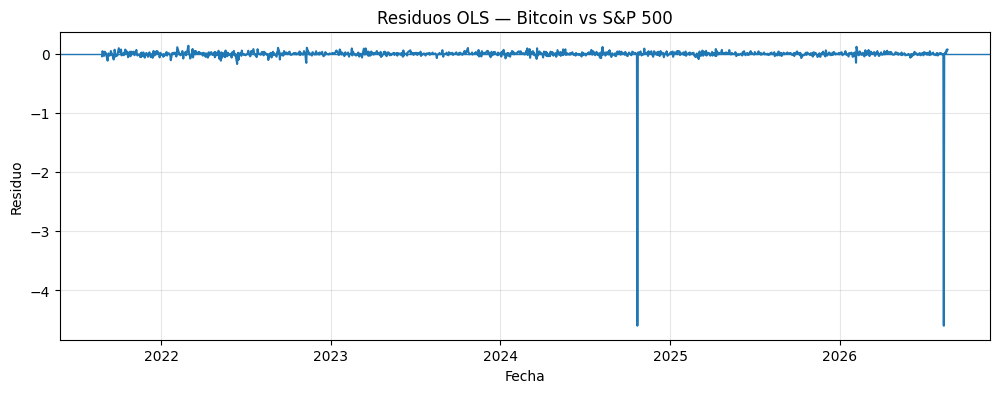

In [ ]:

# ============================================================
# GRÁFICOS DE SUSTENTACIÓN
# ============================================================

# 1. Retornos acumulados de Bitcoin
btc_plot = btc_r.copy().sort_values("Date")
btc_plot["Riqueza"] = np.exp(btc_plot["r_BTC"].cumsum())

plt.figure(figsize=(12,5))
plt.plot(btc_plot["Date"], btc_plot["Riqueza"])
plt.title("Evolución de riqueza acumulada — Bitcoin")
plt.xlabel("Fecha")
plt.ylabel("Índice de riqueza")
plt.grid(True, alpha=0.3)
plt.show()


# 2. Máximo drawdown
wealth = btc_plot["Riqueza"]
drawdown = wealth / wealth.cummax() - 1

plt.figure(figsize=(12,5))
plt.plot(btc_plot["Date"], drawdown)
plt.axhline(0, linewidth=1)
plt.title("Drawdown de Bitcoin")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)
plt.show()


# 3. Distribución de retornos + VaR/CVaR
r = btc_plot["r_BTC"].dropna()
q05 = r.quantile(0.05)
cvar = r[r <= q05].mean()

plt.figure(figsize=(10,5))
plt.hist(r, bins=80)
plt.axvline(q05, linestyle="--", linewidth=2,
            label=f"VaR 5% = {q05:.2%}")
plt.axvline(cvar, linestyle=":", linewidth=2,
            label=f"CVaR 5% = {cvar:.2%}")
plt.title("Distribución de retornos diarios — Bitcoin")
plt.xlabel("Retorno logarítmico")
plt.ylabel("Frecuencia")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# 4. Beta normal vs beta bajista
beta_plot = tabla_final.drop_duplicates("Mercado")

x = np.arange(len(beta_plot))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, beta_plot["Beta"], width, label="Beta normal")
plt.bar(x + width/2, beta_plot["Beta bajista"], width,
        label="Beta bajista")
plt.axhline(1, linestyle="--", linewidth=1)
plt.xticks(x, beta_plot["Mercado"])
plt.ylabel("Beta")
plt.title("Beta normal vs beta bajista — Bitcoin")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.show()


# 5. Comparación de R²
r2_plot = tabla_final.drop_duplicates("Mercado")[["Mercado", "R²"]]

plt.figure(figsize=(9,5))
plt.bar(r2_plot["Mercado"], r2_plot["R²"])
plt.ylabel("R²")
plt.title("Poder explicativo del CAPM según benchmark")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


# 6. CAPM: relación Bitcoin vs NCI
for mercado, data in bases.items():

    modelo = estimate_capm(data, mercado, hac=False)

    xvals = data["excess_market"]
    yvals = data["excess_BTC"]

    xline = np.linspace(xvals.min(), xvals.max(), 200)
    yline = modelo.params["const"] + modelo.params["excess_market"] * xline

    plt.figure(figsize=(8,6))
    plt.scatter(xvals, yvals, alpha=0.30, s=12)
    plt.plot(xline, yline, linewidth=2)
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlabel(f"Retorno en exceso — {mercado}")
    plt.ylabel("Retorno en exceso — Bitcoin")
    plt.title(f"CAPM: Bitcoin vs {mercado}")
    plt.grid(True, alpha=0.3)
    plt.show()


# 7. Residuos: útil para justificar HAC
for mercado, data in bases.items():

    modelo = estimate_capm(data, mercado, hac=False)

    plt.figure(figsize=(12,4))
    plt.plot(data["Date"], modelo.resid)
    plt.axhline(0, linewidth=1)
    plt.title(f"Residuos OLS — Bitcoin vs {mercado}")
    plt.xlabel("Fecha")
    plt.ylabel("Residuo")
    plt.grid(True, alpha=0.3)
    plt.show()
